In [1]:
# ============================================
# Notebook 08
# Calendar Analytics
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
project_folder = "Executive_Assistant_Business_Dashboard"

data_folder = os.path.join(project_folder,"data")
reports_folder = os.path.join(project_folder,"reports")
charts_folder = os.path.join(project_folder,"charts")

os.makedirs(reports_folder,exist_ok=True)
os.makedirs(charts_folder,exist_ok=True)

In [3]:
calendar_file = os.path.join(data_folder,"calendar.xlsx")

calendar_df = pd.read_excel(calendar_file)

calendar_df.head()

,Date,Day,Meeting_Hours,Focus_Hours,Travel_Hours,Leave,WFH,Total_Working_Hours
0,2026-01-01,Thursday,2,1,0,No,Yes,3
1,2026-01-02,Friday,2,3,1,Yes,Yes,6
2,2026-01-03,Saturday,3,3,1,No,No,7
3,2026-01-04,Sunday,3,1,2,No,Yes,6
4,2026-01-05,Monday,4,2,0,Yes,No,6


In [4]:
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 365 non-null    datetime64[ns]
 1   Day                  365 non-null    object        
 2   Meeting_Hours        365 non-null    int64         
 3   Focus_Hours          365 non-null    int64         
 4   Travel_Hours         365 non-null    int64         
 5   Leave                365 non-null    object        
 6   WFH                  365 non-null    object        
 7   Total_Working_Hours  365 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 22.9+ KB


In [5]:
calendar_df.isnull().sum()

Date                   0
Day                    0
Meeting_Hours          0
Focus_Hours            0
Travel_Hours           0
Leave                  0
WFH                    0
Total_Working_Hours    0
dtype: int64

In [6]:
calendar_df["Date"] = pd.to_datetime(calendar_df["Date"])

calendar_df["Month"] = calendar_df["Date"].dt.month_name()

calendar_df["Week"] = calendar_df["Date"].dt.isocalendar().week

In [7]:
total_meeting = calendar_df["Meeting_Hours"].sum()

total_focus = calendar_df["Focus_Hours"].sum()

total_travel = calendar_df["Travel_Hours"].sum()

total_working = calendar_df["Total_Working_Hours"].sum()

leave_days = (calendar_df["Leave"]=="Yes").sum()

wfh_days = (calendar_df["WFH"]=="Yes").sum()

utilization = round((total_working/(365*8))*100,2)

productivity = round((total_focus/total_working)*100,2)

In [8]:
print("="*60)

print("CALENDAR ANALYTICS DASHBOARD")

print("="*60)

print(f"Meeting Hours      : {total_meeting}")

print(f"Focus Hours        : {total_focus}")

print(f"Travel Hours       : {total_travel}")

print(f"Working Hours      : {total_working}")

print(f"Leave Days         : {leave_days}")

print(f"WFH Days           : {wfh_days}")

print(f"Utilization        : {utilization}%")

print(f"Productivity       : {productivity}%")

CALENDAR ANALYTICS DASHBOARD
Meeting Hours      : 1079
Focus Hours        : 1260
Travel Hours       : 588
Working Hours      : 2927
Leave Days         : 188
WFH Days           : 189
Utilization        : 100.24%
Productivity       : 43.05%


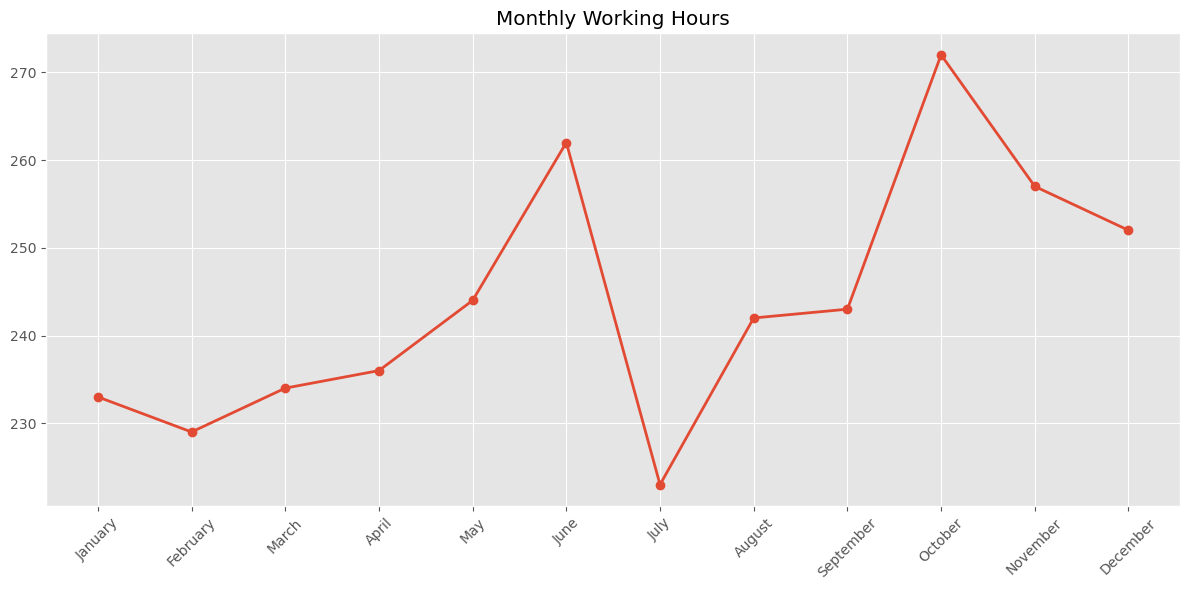

In [9]:
month_order=[
"January","February","March","April","May","June",
"July","August","September","October","November","December"
]

monthly=calendar_df.groupby("Month")["Total_Working_Hours"].sum()

monthly=monthly.reindex(month_order)

plt.figure(figsize=(12,6))

plt.plot(monthly.index,
         monthly.values,
         marker="o",
         linewidth=2)

plt.xticks(rotation=45)

plt.title("Monthly Working Hours")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Monthly_Working_Hours.png"))

plt.show()

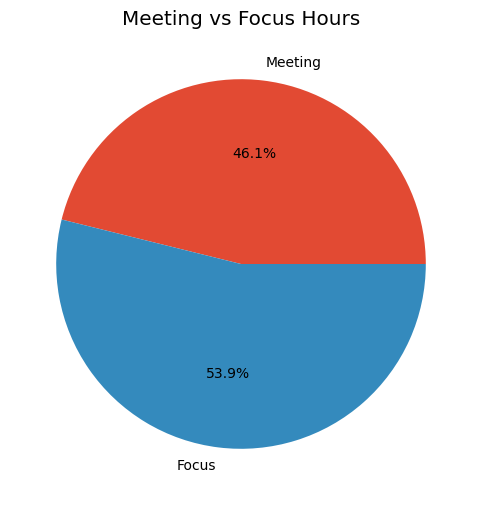

In [10]:
hours = [
    total_meeting,
    total_focus
]

labels = [
    "Meeting",
    "Focus"
]

plt.figure(figsize=(6,6))

plt.pie(
    hours,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Meeting vs Focus Hours")

plt.savefig(os.path.join(charts_folder,"Meeting_vs_Focus.png"))

plt.show()

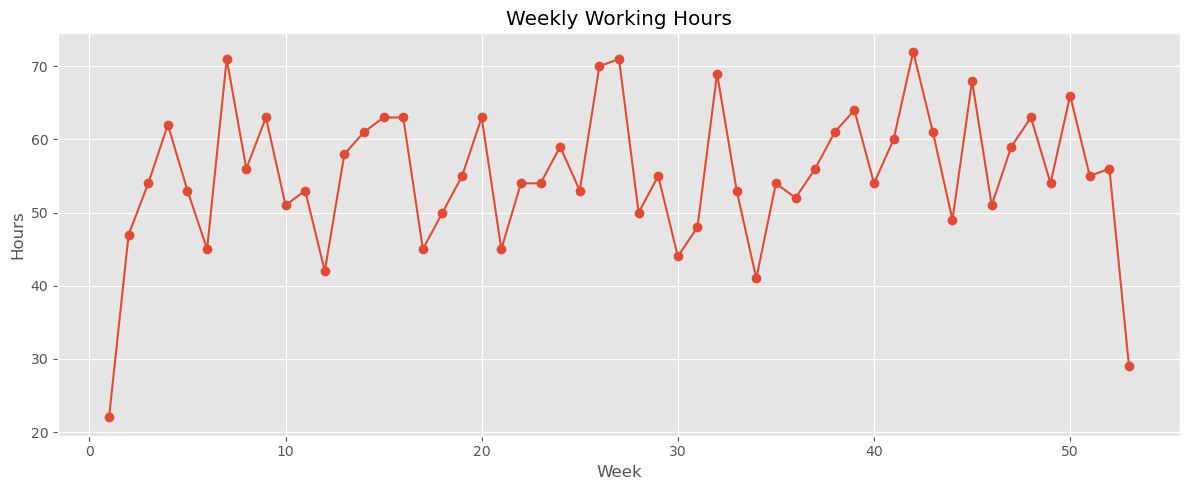

In [11]:
weekly=calendar_df.groupby("Week")["Total_Working_Hours"].sum()

plt.figure(figsize=(12,5))

plt.plot(
    weekly.index,
    weekly.values,
    marker="o"
)

plt.title("Weekly Working Hours")

plt.xlabel("Week")

plt.ylabel("Hours")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Weekly_Trend.png"))

plt.show()

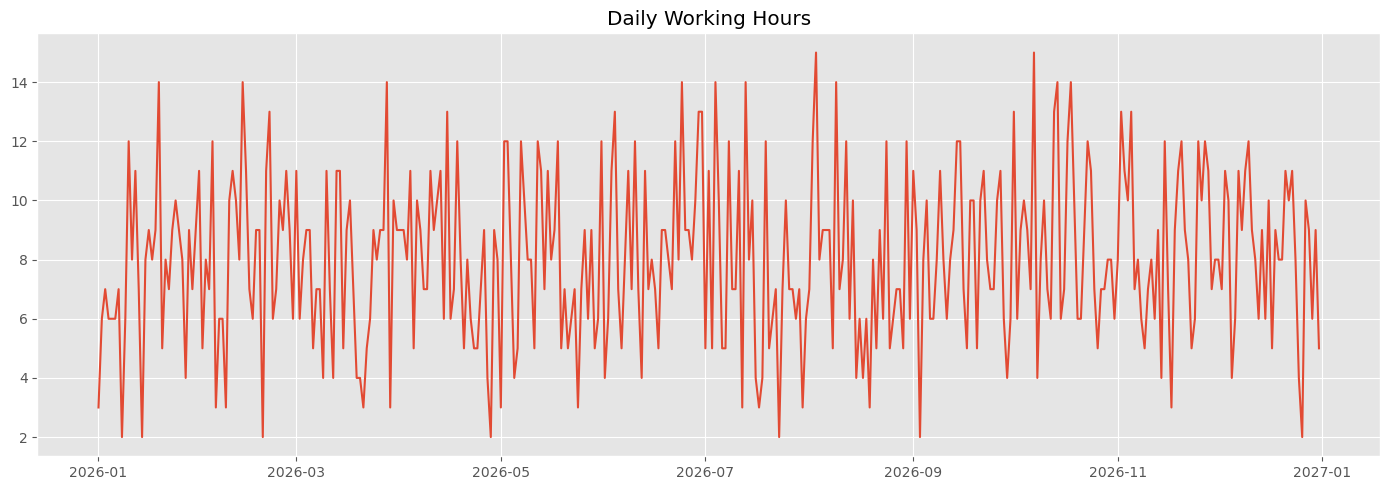

In [12]:
plt.figure(figsize=(14,5))

plt.plot(
    calendar_df["Date"],
    calendar_df["Total_Working_Hours"]
)

plt.title("Daily Working Hours")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Daily_Working_Hours.png"))

plt.show()

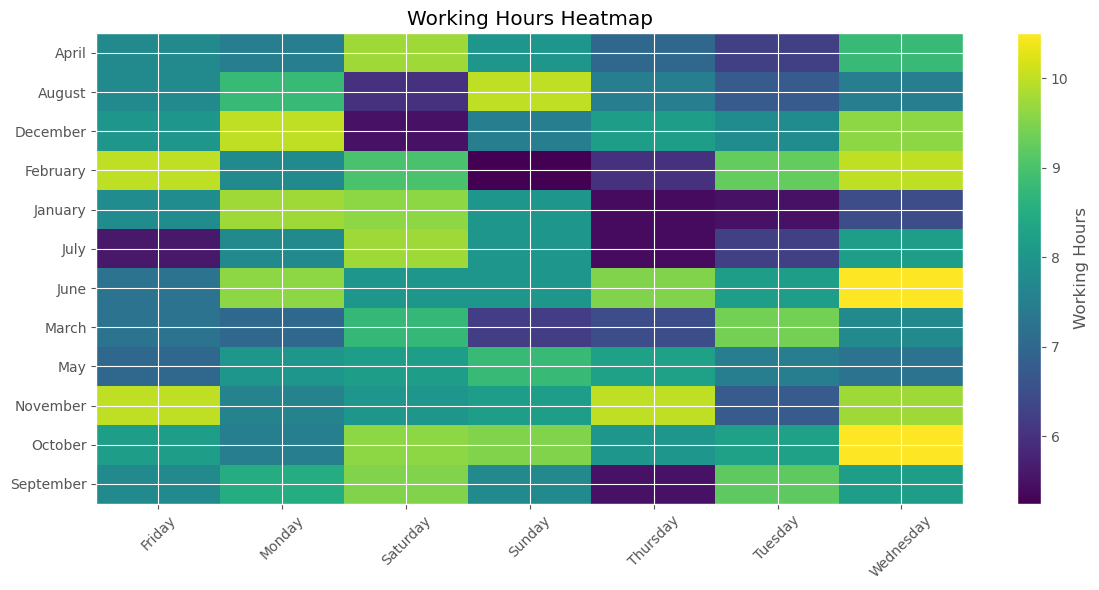

In [13]:
pivot = calendar_df.pivot_table(
    values="Total_Working_Hours",
    index="Month",
    columns="Day",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))

plt.imshow(
    pivot,
    aspect="auto"
)

plt.colorbar(label="Working Hours")

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.title("Working Hours Heatmap")

plt.tight_layout()

plt.savefig(os.path.join(charts_folder,"Working_Heatmap.png"))

plt.show()

In [14]:
summary = pd.DataFrame({

"Metric":[

"Meeting Hours",

"Focus Hours",

"Travel Hours",

"Working Hours",

"Leave Days",

"WFH Days",

"Utilization",

"Productivity"

],

"Value":[

total_meeting,

total_focus,

total_travel,

total_working,

leave_days,

wfh_days,

utilization,

productivity

]

})

summary.to_excel(

os.path.join(

reports_folder,

"Calendar_Summary.xlsx"

),

index=False

)

print("Calendar Summary Saved Successfully")

Calendar Summary Saved Successfully


In [15]:
print("="*60)

print("CALENDAR ANALYTICS COMPLETED")

print("="*60)

print(f"Charts Saved  : {charts_folder}")

print(f"Reports Saved : {reports_folder}")

print("="*60)

CALENDAR ANALYTICS COMPLETED
Charts Saved  : Executive_Assistant_Business_Dashboard\charts
Reports Saved : Executive_Assistant_Business_Dashboard\reports
